Referências

https://huggingface.co/CompVis/stable-diffusion-v-1-4-original

https://huggingface.co/docs/diffusers/main/en/api/diffusion_pipeline

https://github.com/Stability-AI/stablediffusion

https://huggingface.co/stabilityai/stable-diffusion-2-1

### Setup

First, please make sure you are using a GPU runtime to run this notebook, so inference is much faster.

In [ ]:
!nvidia-smi

Wed Dec 10 00:34:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Next, you should install `diffusers` as well `scipy`, `ftfy` and `transformers`. `accelerate` is used to achieve much faster loading.

In [ ]:
!pip install diffusers transformers
!pip install scipy ftfy accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


### Stable Diffusion Pipeline

`StableDiffusionPipeline` is an end-to-end inference pipeline that you can use to generate images from text with just a few lines of code.

First, we load the pre-trained weights of all components of the model. In this notebook we use Stable Diffusion version 1.4 ([CompVis/stable-diffusion-v1-4](https://huggingface.co/CompVis/stable-diffusion-v1-4)), but there are other variants that you may want to try:
* [runwayml/stable-diffusion-v1-5](https://huggingface.co/runwayml/stable-diffusion-v1-5)
* [stabilityai/stable-diffusion-2-1-base](https://huggingface.co/stabilityai/stable-diffusion-2-1-base)
* [stabilityai/stable-diffusion-2-1](https://huggingface.co/stabilityai/stable-diffusion-2-1). This version can produce images with a resolution of 768x768, while the others work at 512x512.

In addition to the model id [CompVis/stable-diffusion-v1-4](https://huggingface.co/CompVis/stable-diffusion-v1-4), we're also passing a specific `revision` and `torch_dtype` to the `from_pretrained` method.

We want to ensure that every free Google Colab can run Stable Diffusion, hence we're loading the weights from the half-precision branch [`fp16`](https://huggingface.co/CompVis/stable-diffusion-v1-4/tree/fp16) and also tell `diffusers` to expect the weights in float16 precision by passing `torch_dtype=torch.float16`.

If you want to ensure the highest possible precision, please make sure to remove `torch_dtype=torch.float16` at the cost of a higher memory usage.

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda"

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, use_safetensors=True)
pipe = pipe.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/50 [00:00<?, ?it/s]

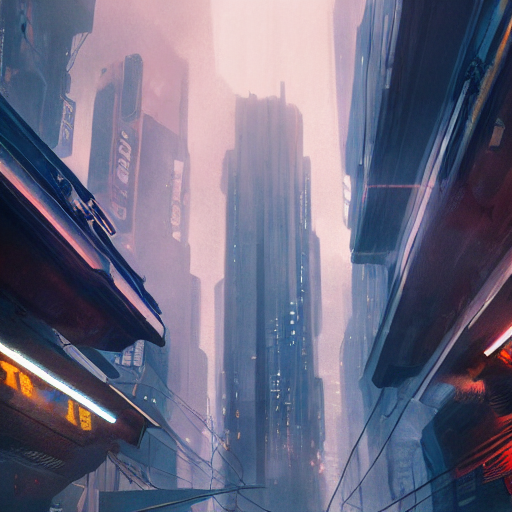

In [ ]:
prompt = "portrait art of street and buildings blade runner 8 k ultra realistic, lens flare, atmosphere, glow, detailed, intricate, full of colour, cinematic lighting, trending on artstation, 4 k, hyperrealistic, focused, extreme details, unreal engine 5, cinematic, masterpiece"
pipe.enable_attention_slicing()
image = pipe(prompt).images[0]

image.save("blade_runner.png")

image

  0%|          | 0/50 [00:00<?, ?it/s]

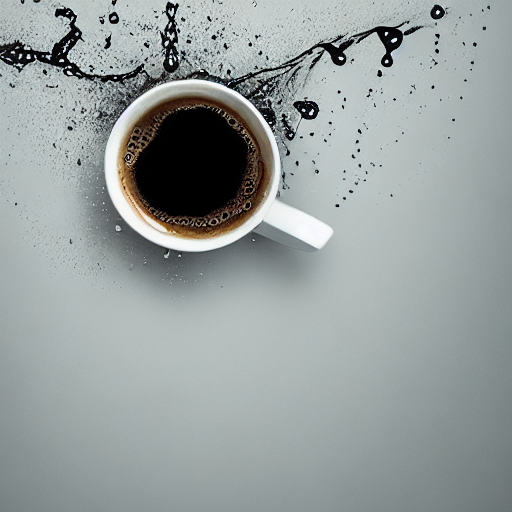

In [ ]:
prompt = "The image captures a splash of coffee and cream inside a cup. . The suspended droplets and the smooth interplay of light and dark hues create a visually striking scene that portrays the elegant flow and contrast between the two liquids."
pipe.enable_attention_slicing()
image = pipe(prompt).images[0]

image.save("cafe_3.png")

image

  0%|          | 0/50 [00:00<?, ?it/s]

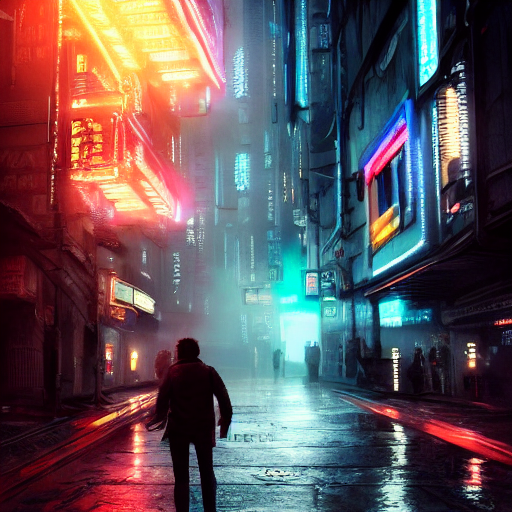

In [ ]:
prompt = "portrait art of street and buildings blade runner 8 k ultra realistic, lens flare, atmosphere, glow, detailed, intricate, full of colour, cinematic lighting, trending on artstation, 4 k, hyperrealistic, focused, extreme details, unreal engine 5, cinematic, masterpiece"
pipe.enable_attention_slicing()
image = pipe(prompt).images[0]

image.save("blade_runner.png")

image

In [ ]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

model_id = "stabilityai/stable-diffusion-2-1"

# Use the DPMSolverMultistepScheduler (DPM-Solver++) scheduler here instead
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to("cuda")

In [ ]:
prompt = "portrait art of street and buildings blade runner 8 k ultra realistic, lens flare, atmosphere, glow, detailed, intricate, full of colour, cinematic lighting, trending on artstation, 4 k, hyperrealistic, focused, extreme details, unreal engine 5, cinematic, masterpiece"
image = pipe(prompt).images[0]

image.save("blade_runner_v2.1.png")

image

In [ ]:
prompt = "The image captures a splash of coffee and cream inside a cup. . The suspended droplets and the smooth interplay of light and dark hues create a visually striking scene that portrays the elegant flow and contrast between the two liquids."
image = pipe(prompt).images[0]

image.save("cafe_3.png")

image

In [ ]:
# Stable Diffusion 1.5 produces images of 512 × 512 pixels by default.
# Make sure height and width are both multiples of 8
# The best way to create non-square images is to use 512 in one dimension, and a value larger than that in the other one

image = pipe(prompt, height=1024, width=1024).images[0]
image

In [ ]:
model_id = "Nihirc/Prompt2MedImage"
device = "cuda"

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)

model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/912 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

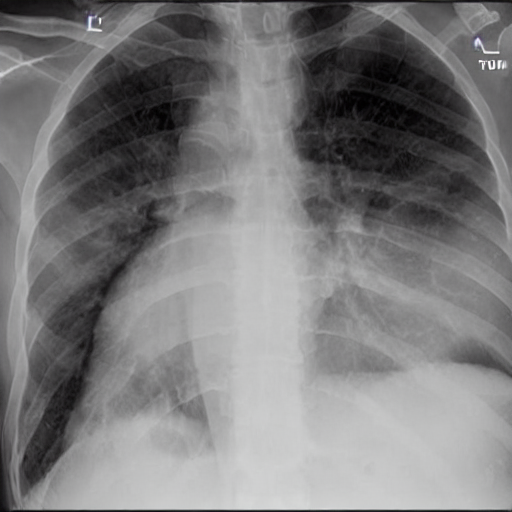

In [ ]:
prompt = "photo of a lung xray with visible pleural effusion."
image = pipe(prompt).images[0]

image.save("lung.png")

image

  0%|          | 0/50 [00:00<?, ?it/s]

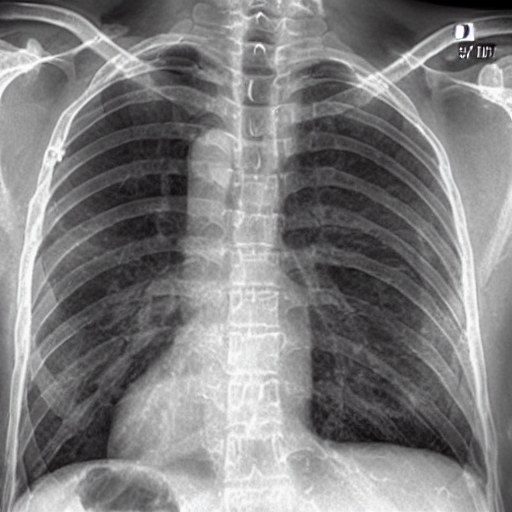

In [ ]:
prompt = "Generate a medical X-ray of a human chest showing pneumonia."
image = pipe(prompt).images[0]

image.save("lung.png")

image